## 1. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import joblib
warnings.filterwarnings('ignore')

from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)
from imblearn.over_sampling import SMOTE

# ── Configuration ──────────────────────────────────────
DATA_PATH    = 'dataset.csv'
WINDOW_SIZE  = 28       # samples per window  (28 × 0.5 s = 14 s at 2 Hz)
STEP_SIZE    = 14       # 50% overlap between windows
TEST_SIZE    = 0.20
RANDOM_STATE = 42

FEATURES = ['GyroX', 'GyroY', 'GyroZ', 'AccX', 'AccY', 'AccZ']

CLASS_NAMES = {
    0: 'Idle State',
    1: 'Normal Driving',
    2: 'Sudden Acceleration',
    3: 'Sudden Right Turn',
    4: 'Sudden Left Turn',
    5: 'Sudden Brake',
}

HARSH_CLASSES = {2, 3, 4, 5}   # labels that count as harsh driving

print('Libraries loaded successfully.')
print(f'Window: {WINDOW_SIZE} samples = {WINDOW_SIZE * 0.5:.0f} s at 2 Hz')


Libraries loaded successfully.
Window: 28 samples = 14 s at 2 Hz


## 2. Load & Inspect Dataset

In [3]:
df = pd.read_csv(DATA_PATH)

print(f'Shape  : {df.shape}')
print(f'Columns: {list(df.columns)}')
print()
print('Label distribution:')
counts = df['label'].value_counts().sort_index()
for lbl, cnt in counts.items():
    bar  = chr(9608) * int(30 * cnt / counts.max())
    warn = '  <<< collect more data' if cnt < 300 else ''
    print(f'  {lbl}  {CLASS_NAMES[lbl]:<22}  {bar:<30}  {cnt}{warn}')

print()
df.describe().round(4)


Shape  : (26882, 7)
Columns: ['label', 'GyroX', 'GyroY', 'GyroZ', 'AccX', 'AccY', 'AccZ']

Label distribution:
  0  Idle State              ███████████████                 3288
  1  Normal Driving          █████████████████               3746
  2  Sudden Acceleration     █████████████████████           4485
  3  Sudden Right Turn       ████████████████████████        5133
  4  Sudden Left Turn        ██████████████████████████████  6249
  5  Sudden Brake            ███████████████████             3981



,label,GyroX,GyroY,GyroZ,AccX,AccY,AccZ
count,26882.0000,26882.0000,26882.0000,26882.0000,26882.0000,26882.0000,26882.0000
mean,2.7162,-0.6366,4.1302,0.8420,0.1710,-0.0836,-0.5529
std,1.6029,1.6941,2.6580,5.9446,0.1672,0.0979,0.8297
min,0.0000,-25.6490,-34.9262,-50.2595,-0.4836,-0.7935,-1.5051
25%,1.0000,-1.3599,3.4351,-0.1603,0.0862,-0.1542,-0.9978
50%,3.0000,-0.4580,4.2116,0.6565,0.2133,-0.0982,-0.9720
75%,4.0000,0.0354,4.8430,1.7290,0.2924,-0.0014,-0.9207
max,5.0000,30.9846,43.3181,45.4427,0.7478,0.7686,1.7251


## 3. Visualise Raw Sensor Signals

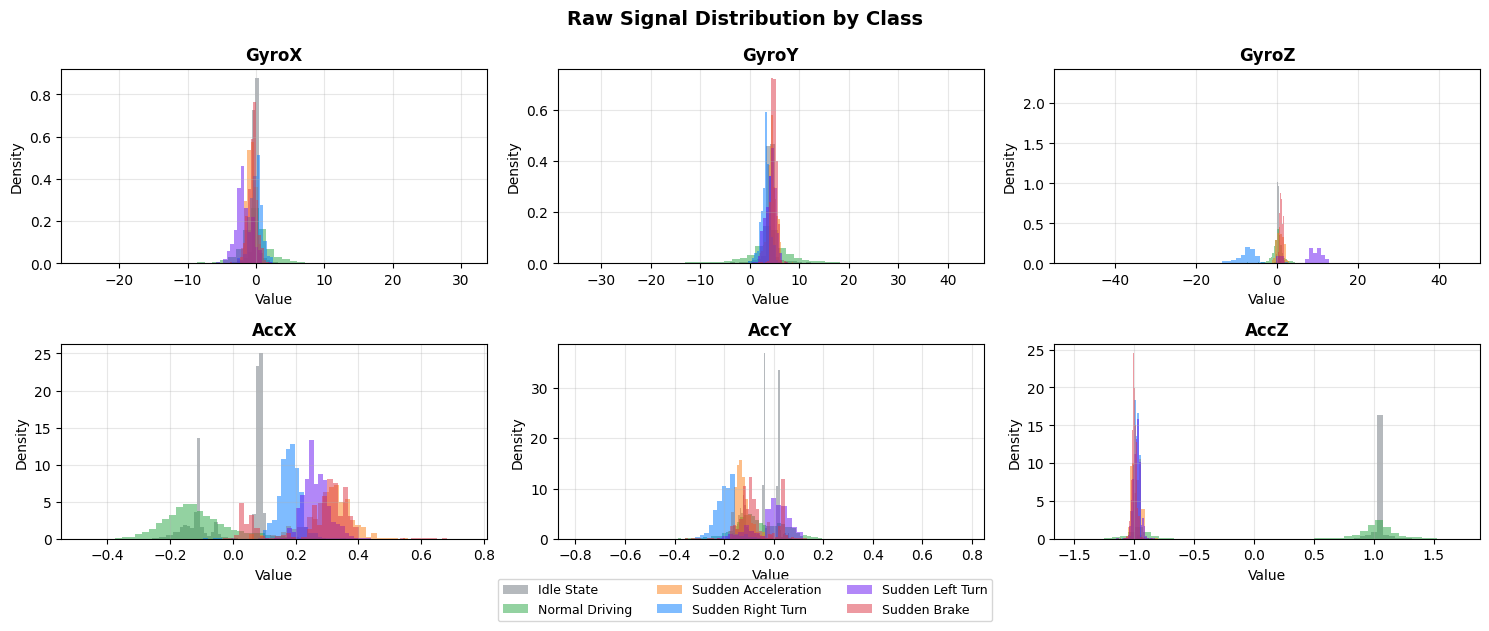

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
fig.suptitle('Raw Signal Distribution by Class', fontsize=14, fontweight='bold')

colors = ['#6c757d', '#28a745', '#fd7e14', '#007bff', '#6610f2', '#dc3545']

for ax, feat in zip(axes.flatten(), FEATURES):
    for lbl in sorted(df['label'].unique()):
        subset = df[df['label'] == lbl][feat]
        ax.hist(subset, bins=50, alpha=0.5, label=CLASS_NAMES[lbl],
                color=colors[lbl], density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)

handles, labels_leg = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.05), fontsize=9)
plt.tight_layout()
plt.show()


## 4. Sliding Window Feature Extraction

Each window of **28 samples (14 s)** is compressed to **48 statistical features** (mean, std, min, max, Q1, Q3, RMS, range — for each of the 6 axes).


In [5]:
def window_features(window: np.ndarray) -> np.ndarray:
    """
    Input : (WINDOW_SIZE, 6) array
    Output: 1-D vector of 48 features (8 stats x 6 axes)

    Gyro axes (cols 0-2) are mean-centered per window to remove the
    per-sensor DC bias (e.g. the ~+4 deg/s GyroY offset baked into this
    dataset). A gyro at rest should read 0, so subtracting the window
    mean makes the features describe motion dynamics rather than the
    absolute sensor offset -- this lets them transfer across devices
    whose gyros have different biases. Accel (cols 3-5) is left intact:
    its DC component is real gravity/tilt information.
    The SAME centering MUST be applied at inference (classifier.cpp /
    main.py) before computing these features.
    """
    window = window.astype(np.float64).copy()
    window[:, 0:3] -= window[:, 0:3].mean(axis=0)

    feats = []
    for col in range(window.shape[1]):
        s = window[:, col]
        feats.extend([
            s.mean(),
            s.std(),
            s.min(),
            s.max(),
            np.percentile(s, 25),
            np.percentile(s, 75),
            np.sqrt(np.mean(s ** 2)),   # RMS energy
            s.max() - s.min(),          # range
        ])
    return np.array(feats)


def extract_windows(dataframe, window_size=WINDOW_SIZE, step_size=STEP_SIZE):
    """
    Slide a window over the dataset with 50% overlap.
    Label for each window = majority label of samples inside it.
    Returns X (n_windows, 48) and y (n_windows,).
    """
    X, y = [], []
    data   = dataframe[FEATURES].values
    labels = dataframe['label'].values

    for start in range(0, len(data) - window_size + 1, step_size):
        end           = start + window_size
        window        = data[start:end]
        window_labels = labels[start:end]
        majority      = Counter(window_labels).most_common(1)[0][0]
        X.append(window_features(window))
        y.append(majority)

    return np.array(X), np.array(y)


X, y = extract_windows(df)

print(f'Windows extracted : {len(X):,}')
print(f'Feature vector    : {X.shape[1]} features  (8 stats x 6 axes)')
print()
print('Window label distribution:')
for lbl, cnt in sorted(Counter(y).items()):
    print(f'  {lbl}  {CLASS_NAMES[lbl]:<22}  {cnt}')


Windows extracted : 1,919
Feature vector    : 48 features  (8 stats x 6 axes)

Window label distribution:
  0  Idle State              235
  1  Normal Driving          267
  2  Sudden Acceleration     320
  3  Sudden Right Turn       366
  4  Sudden Left Turn        446
  5  Sudden Brake            285


## 5. Train / Test Split + SMOTE Oversampling

SMOTE synthesises extra samples for the minority Idle class so the model doesn't ignore it.


In [6]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_enc,
)

print(f'Train windows : {len(X_train):,}')
print(f'Test  windows : {len(X_test):,}')
print()

# k_neighbors=2 because Idle class has very few samples
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=2)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('After SMOTE (train set):')
for enc_lbl, cnt in sorted(Counter(y_train_sm).items()):
    orig_lbl = int(le.inverse_transform([enc_lbl])[0])
    print(f'  {orig_lbl}  {CLASS_NAMES[orig_lbl]:<22}  {cnt}')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)
print()
print('StandardScaler applied.')


Train windows : 1,535
Test  windows : 384

After SMOTE (train set):
  0  Idle State              357
  1  Normal Driving          357
  2  Sudden Acceleration     357
  3  Sudden Right Turn       357
  4  Sudden Left Turn        357
  5  Sudden Brake            357

StandardScaler applied.


## 6. Train Random Forest Model

Random Forest is chosen for its robustness to class imbalance, built-in feature importance, and reliable probability outputs needed for the two-stage detection logic.


In [7]:
model = RandomForestClassifier(
    n_estimators     = 200,
    max_depth        = None,
    min_samples_leaf = 2,
    class_weight     = 'balanced',
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
)

model.fit(X_train_sc, y_train_sm)

print('Model trained successfully.')
print(f'  Estimators : {model.n_estimators}')
print(f'  Features   : {model.n_features_in_}')
print(f'  Classes    : {list(le.classes_)}')


Model trained successfully.
  Estimators : 200
  Features   : 48
  Classes    : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


## 7. Model Evaluation

In [8]:
y_pred = model.predict(X_test_sc)

acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy : {acc * 100:.2f}%')
print()

target_names = [CLASS_NAMES[int(le.inverse_transform([i])[0])] for i in range(len(le.classes_))]
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))


Test Accuracy : 98.44%

                     precision    recall  f1-score   support

         Idle State       0.94      0.96      0.95        47
     Normal Driving       0.96      0.94      0.95        54
Sudden Acceleration       1.00      0.98      0.99        64
  Sudden Right Turn       0.99      1.00      0.99        73
   Sudden Left Turn       1.00      1.00      1.00        89
       Sudden Brake       1.00      1.00      1.00        57

           accuracy                           0.98       384
          macro avg       0.98      0.98      0.98       384
       weighted avg       0.98      0.98      0.98       384



### 7.1 Confusion Matrix

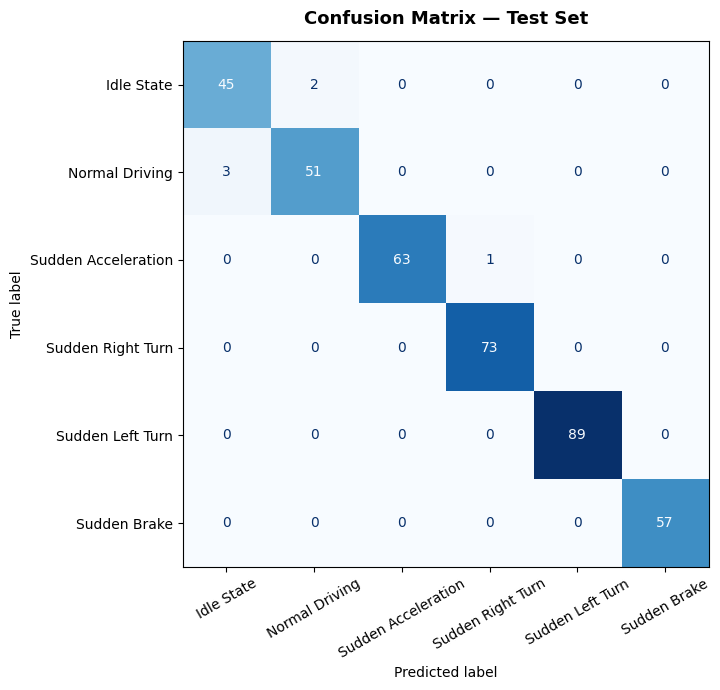

In [9]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


### 7.2 Feature Importance

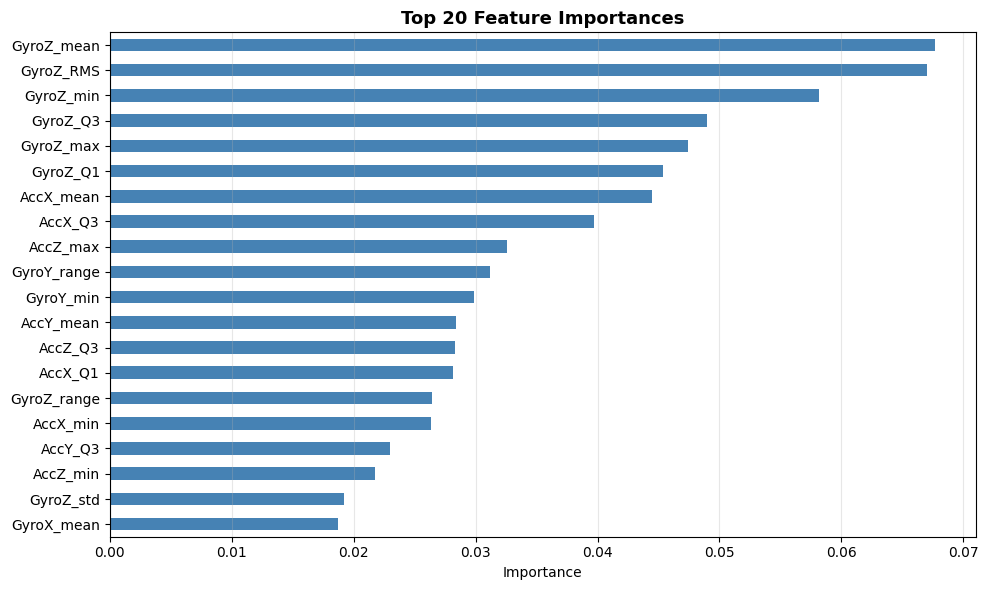

In [10]:
stat_names = ['mean', 'std', 'min', 'max', 'Q1', 'Q3', 'RMS', 'range']
feat_names = [f'{ax}_{st}' for ax in FEATURES for st in stat_names]

importances = pd.Series(model.feature_importances_, index=feat_names)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### 7.3 Stratified 5-Fold Cross Validation

In [11]:
sc_cv     = StandardScaler()
X_sc_full = sc_cv.fit_transform(X)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    X_sc_full, y_enc, cv=cv, scoring='accuracy'
)

print(f'CV Accuracy : {cv_scores.mean()*100:.2f}% +/- {cv_scores.std()*100:.2f}%')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i} : {s*100:.2f}%')


CV Accuracy : 99.01% +/- 0.38%
  Fold 1 : 98.70%
  Fold 2 : 99.48%
  Fold 3 : 99.22%
  Fold 4 : 99.22%
  Fold 5 : 98.43%


## 8. Save Model & Artefacts

In [12]:
joblib.dump(model,  'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le,     'label_encoder.pkl')

print('Saved:')
print('  rf_model.pkl       -- trained Random Forest')
print('  scaler.pkl         -- StandardScaler (fit on training data)')
print('  label_encoder.pkl  -- LabelEncoder (int labels <-> encoded indices)')


Saved:
  rf_model.pkl       -- trained Random Forest
  scaler.pkl         -- StandardScaler (fit on training data)
  label_encoder.pkl  -- LabelEncoder (int labels <-> encoded indices)


In [13]:
# ── Cell: Build & Train MLP ───────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras

# Build the network
mlp_model = keras.Sequential([
    keras.layers.Input(shape=(48,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(6,  activation='softmax'),
], name='driver_behaviour_mlp')

mlp_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy'],
)

mlp_model.summary()

# Train — X_train_sc and y_train_sm are already in memory from Section 5
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5
)

history = mlp_model.fit(
    X_train_sc, y_train_sm,
    epochs          = 100,
    batch_size      = 32,
    validation_split= 0.15,
    callbacks       = [early_stop, reduce_lr],
    verbose         = 1,
)

# Compare MLP vs Random Forest accuracy
mlp_acc = mlp_model.evaluate(X_test_sc, y_test, verbose=0)[1]
rf_acc  = accuracy_score(y_test, model.predict(X_test_sc))

print(f'\nRandom Forest accuracy : {rf_acc  * 100:.2f}%')
print(f'MLP accuracy           : {mlp_acc * 100:.2f}%')

Model: "driver_behaviour_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,414 (21.15 KB)

 Trainable params: 5,414 (21.15 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6665 - loss: 0.9279 - val_accuracy: 0.8602 - val_loss: 0.8337 - learning_rate: 0.0010
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9137 - loss: 0.3337 - val_accuracy: 0.9037 - val_loss: 0.3804 - learning_rate: 0.0010
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9209 - loss: 0.2315 - val_accuracy: 0.9472 - val_loss: 0.2619 - learning_rate: 0.0010
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9330 - loss: 0.1805 - val_accuracy: 0.9441 - val_loss: 0.2058 - learning_rate: 0.0010
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9555 - loss: 0.1390 - val_accuracy: 0.9689 - val_loss: 0.1495 - learning_rate: 0.0010
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9714 - loss: 0.1078 - val_accuracy: 0.9907 - val_loss: 0.1038 - learning_rate: 0.0010
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9791 - loss: 0.0877 - val_acc

In [14]:
# ── Cell: Convert MLP → TFLite ────────────────────────────────────────────────
import numpy as np

# 1. Convert — pure float32, no quantization (required for this TFLM version)
converter    = tf.lite.TFLiteConverter.from_keras_model(mlp_model)
tflite_model = converter.convert()

# 2. Save
TFLITE_PATH = 'driver_behaviour_mlp.tflite'
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

print(f'Saved: {TFLITE_PATH}')
print(f'Size : {len(tflite_model):,} bytes  ({len(tflite_model)/1024:.1f} KB)')

# 3. Verify TFLite accuracy matches Keras
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
inp_idx = interpreter.get_input_details()[0]['index']
out_idx = interpreter.get_output_details()[0]['index']

preds = []
for sample in X_test_sc:
    interpreter.set_tensor(inp_idx, sample.reshape(1, -1).astype(np.float32))
    interpreter.invoke()
    preds.append(np.argmax(interpreter.get_tensor(out_idx)))

tflite_acc = np.mean(np.array(preds) == y_test)
print(f'\nKeras  accuracy : {mlp_acc    * 100:.2f}%')
print(f'TFLite accuracy : {tflite_acc * 100:.2f}%')
print(f'Difference      : {abs(mlp_acc - tflite_acc) * 100:.3f}%  (should be < 0.1%)')

# 4. Print scaler values as C arrays — copy these into main.cpp
print('\n// ── Paste into main.cpp ─────────────────────────────')
print(f'static const float SCALER_MEAN[48] = {{')
print('    ' + ', '.join(f'{v:.8f}f' for v in scaler.mean_))
print('};\n')
print(f'static const float SCALER_SCALE[48] = {{')
print('    ' + ', '.join(f'{v:.8f}f' for v in scaler.scale_))
print('};')

# 5. Confirm class order for main.cpp
print('\n// ── CLASS_NAMES order ───────────────────────────────')
for enc, orig in enumerate(le.classes_):
    print(f'//  {enc} → {CLASS_NAMES[int(orig)]}')


INFO:tensorflow:Assets written to: /tmp/tmp38l69w8w/assets


INFO:tensorflow:Assets written to: /tmp/tmp38l69w8w/assets


Saved artifact at '/tmp/tmp38l69w8w'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  140390482181968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140390482179856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140390482177168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140390482180816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140390482181008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140390482178896: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved: driver_behaviour_mlp.tflite
Size : 24,020 bytes  (23.5 KB)


W0000 00:00:1780986936.684959   38651 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1780986936.684970   38651 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1780986936.685647   38651 reader.cc:83] Reading SavedModel from: /tmp/tmp38l69w8w
I0000 00:00:1780986936.685884   38651 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1780986936.685887   38651 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp38l69w8w
I0000 00:00:1780986936.688547   38651 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1780986936.688828   38651 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1780986936.704477   38651 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp38l69w8w
I0000 00:00:1780986936.708263   38651 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 22624 microseconds.
I0000 00:00:1780986936.729913   38651


Keras  accuracy : 98.18%
TFLite accuracy : 98.18%
Difference      : 0.000%  (should be < 0.1%)

// ── Paste into main.cpp ─────────────────────────────
static const float SCALER_MEAN[48] = {
    -0.52660075f, 0.92552432f, -2.46971791f, 1.42646365f, -1.08713346f, 0.02858994f, 1.27643845f, 3.89618156f, 4.16019767f, 1.45395997f, 0.95809761f, 7.31645806f, 3.32783283f, 4.99534288f, 4.73456197f, 6.35836046f, 0.50716550f, 1.28830385f, -2.02102969f, 2.65010864f, -0.24544190f, 1.32955882f, 3.53321934f, 4.67113833f, 0.15297517f, 0.04737416f, 0.07190084f, 0.24876506f, 0.11952566f, 0.18406218f, 0.21576459f, 0.17686422f, -0.08225364f, 0.03524866f, -0.15398596f, -0.01671209f, -0.10452421f, -0.05852724f, 0.10989266f, 0.13727387f, -0.44440470f, 0.04404843f, -0.53592140f, -0.35092079f, -0.47071570f, -0.41798094f, 1.00030717f, 0.18500062f
};

static const float SCALER_SCALE[48] = {
    0.79834809f, 1.11725889f, 2.70796325f, 2.99170242f, 0.96787476f, 1.03103484f, 1.18059936f, 5.23526673f, 0.81953465f, 2

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
